<div style="font-family: Arial, Helvetica, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/main/dados/logo-sigmoidal.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Aula 1: Introdução à visão computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Introdução à visão computacional

**Da formação da imagem à interpretação de uma cena aérea**

Uma aplicação de busca e resgate precisa relacionar os valores de uma imagem a objetos e situações de interesse. Essa relação depende tanto da captura quanto do método de análise. Antes de escolher um modelo, é necessário compreender a informação disponível nos pixels e a tarefa que se pretende resolver.

Nesta aula, uma cena tridimensional controlada será observada sob diferentes condições. A investigação acompanha uma única pergunta: **quais fatores afetam a identificação de uma pessoa em uma imagem aérea?**

Ao final, será possível explicar a relação entre captura e representação digital, inspecionar uma imagem com NumPy, comparar resolução e condições de observação e avaliar as limitações de uma regra simples de segmentação. O percurso requer Python básico e não utiliza GPU.

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosfab/bootcamp-visao-computacional-drones/blob/main/introducao-visao-computacional.ipynb)

## A tarefa define o significado da saída

Visão computacional reúne métodos para extrair informações de imagens e vídeos. Uma imagem pode ser usada em tarefas diferentes; a saída esperada precisa ser definida antes da implementação.

| Tarefa | Saída típica | Exemplo no contexto de drones |
|---|---|---|
| Classificação | Rótulo de uma imagem ou recorte | Indicar se um recorte contém uma pessoa |
| Detecção de objetos | Localização e categoria de cada instância detectada | Delimitar pessoas por caixas na imagem |
| Segmentação semântica | Categoria atribuída a cada pixel | Separar pixels de pessoas, vegetação e terreno |
| Rastreamento | Associação de identidades ao longo do tempo | Acompanhar o mesmo veículo entre quadros |

A segmentação por cor que será implementada nesta aula seleciona pixels por um atributo visual. A correspondência desse atributo com a categoria “pessoa” será investigada, e não pressuposta.

![Cena de referência: uma pessoa, uma trilha, vegetação e uma lona laranja. Trata-se de uma imagem sintética, preparada para permitir comparações controladas.](https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/main/dados/cena-25m.png)

Cena de referência: uma pessoa, uma trilha, vegetação e uma lona laranja. Trata-se de uma imagem sintética, preparada para permitir comparações controladas.

## Da cena tridimensional à imagem

Em uma câmera física, a iluminação e as propriedades dos materiais determinam a luz que chega ao sistema óptico. O sensor integra o sinal durante a exposição; amostragem, conversão eletrônica e processamento produzem a representação digital. A imagem final depende de toda essa cadeia.

O experimento utiliza uma cena e uma câmera virtuais. Os arquivos RGB representam o resultado de uma renderização, com processamento de cor, e não medições de um sensor real. Esse controle permite alterar a posição da câmera, a orientação da iluminação ou a presença de um oclusor e examinar seus efeitos.

![Vista externa da cena e da câmera. As linhas delimitam o volume de visão e sua interseção com o plano de referência do terreno. Esta ilustração é observada por uma câmera externa; não corresponde à imagem capturada pela câmera do drone. O símbolo do drone é esquemático.](https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/main/dados/geometria-captura.png)

Vista externa da cena e da câmera. As linhas delimitam o volume de visão e sua interseção com o plano de referência do terreno. Esta ilustração é observada por uma câmera externa; não corresponde à imagem capturada pela câmera do drone. O símbolo do drone é esquemático.

### Projeção perspectiva

O modelo **pinhole** representa a geometria da câmera por um centro de projeção. Para um ponto $\mathbf{p}=[X,Y,Z]^\top$ no sistema da câmera, com $Z>0$, a projeção em um plano virtual à frente do centro satisfaz

$$x=f\frac{X}{Z}, \qquad y=f\frac{Y}{Z}.$$

$f$ é a distância focal; $X$, $Y$, $Z$, $x$ e $y$ usam unidades de comprimento compatíveis. As coordenadas acima são geométricas, relativas ao centro da imagem; não são os índices de linha e coluna de um array.

Para pixels quadrados, com $f_x=f_y$, e um segmento de comprimento $L$ paralelo ao plano da imagem, com profundidade constante, o comprimento projetado em pixels é $s_{\mathrm{px}}=f_xL/Z$, em que $f_x$ representa a distância focal em pixels. A divisão por $Z$ explica a redução do tamanho aparente com o aumento da profundidade, nessas condições. Lentes reais acrescentam efeitos que esse modelo idealizado não descreve.

## Ambiente e arquivos

Este notebook utiliza NumPy, Pillow e Matplotlib. No Colab, execute as células em ordem; a primeira baixa os arquivos necessários do repositório público. Os dados ficam na pasta `dados` da sessão.

Para executar localmente, clone o repositório e prepare o ambiente conforme o README. Os arquivos já estarão disponíveis em `dados`. GPU não é necessária.

In [1]:
from pathlib import Path
import json, subprocess
base_url = "https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/main/dados/"
pasta_dados = Path("dados")
pasta_dados.mkdir(exist_ok=True)
arquivos = ["metadados.json"] + [f"{t}-{v}.png" for t in ["cena", "pessoa"] for v in ["25m", "50m", "luz", "oclusao"]]
for nome in arquivos:
    destino = pasta_dados / nome
    if not destino.exists():
        subprocess.run(["wget", "-q", "-T", "30", "-t", "2", base_url + nome, "-O", str(destino) + ".part"], check=True)
        Path(str(destino) + ".part").replace(destino)
metadados = json.loads((pasta_dados / "metadados.json").read_text())

As bibliotecas abaixo serão utilizadas para representar os valores, abrir os arquivos e comparar os resultados visualmente.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({
    "figure.figsize": (7, 5), "font.size": 12,
    "font.family": "DejaVu Sans", "mathtext.fontset": "dejavusans",
    "axes.grid": False, "lines.linewidth": 2,
})

## A imagem como um array

Uma imagem RGB pode ser representada por um tensor $\boldsymbol{\ell}$ com dimensões $H\times W\times 3$: altura, largura e canais. No arquivo utilizado, cada canal é codificado em oito bits sem sinal, com valores possíveis de 0 a 255.

**Amostragem** diz respeito à representação espacial em uma grade. **Quantização** diz respeito aos níveis numéricos disponíveis. Ter 256 níveis por canal não significa ter 256 classes de objetos nem 256 posições na imagem.

Os valores RGB exportados incluem transformações de cor e não devem ser interpretados diretamente como radiância, temperatura ou contagem de fótons.

Formato: (640, 640, 3)
Tipo: uint8
Faixa observada: 9 255


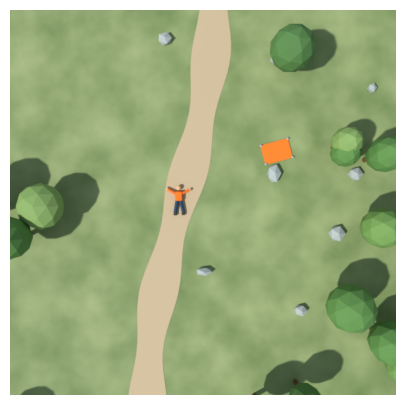

In [3]:
imagem = np.array(Image.open(pasta_dados / "cena-25m.png").convert("RGB"))
print("Formato:", imagem.shape)
print("Tipo:", imagem.dtype)
print("Faixa observada:", imagem.min(), imagem.max())
plt.imshow(imagem)
plt.axis("off")
plt.show()

### Coordenadas e um pixel

No NumPy, a indexação desta imagem é `imagem[linha, coluna, canal]`. O índice de linha cresce para baixo e o de coluna cresce para a direita; a origem é o canto superior esquerdo. A posição abaixo foi escolhida para inspecionar a roupa da pessoa.

Na notação matemática de imagens adotada no curso, $\boldsymbol{\ell}[n,m]$ usa $n$ para coluna e $m$ para linha, com origem inferior esquerda. A conversão para o array precisa respeitar a orientação: para uma imagem com $H$ linhas, `linha = H - 1 - m` e `coluna = n`. Neste notebook, a implementação e os gráficos de imagens utilizam explicitamente a convenção do NumPy.

In [4]:
linha, coluna = 312, 278
pixel = imagem[linha, coluna]
print("RGB:", pixel)
print("R:", pixel[0], "G:", pixel[1], "B:", pixel[2])

RGB: [255 138  58]
R: 255 G: 138 B: 58


### Região de interesse

Uma **região de interesse**, ou ROI, é uma parte da imagem escolhida para análise. O recorte abaixo é definido manualmente; suas coordenadas não foram estimadas por um detector.

No slicing, o limite final é excluído. O intervalo de linhas `270:360` e o de colunas `235:325` produzem uma região de 90 por 90 pixels.

Formato do recorte: (90, 90, 3)


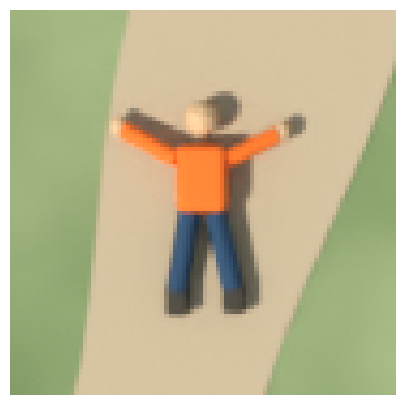

In [5]:
recorte = imagem[270:360, 235:325]
print("Formato do recorte:", recorte.shape)
plt.imshow(recorte, interpolation="nearest")
plt.axis("off")
plt.show()

A ampliação da ROI na tela facilita a inspeção dos pixels existentes. Ela não acrescenta informação que não foi registrada. Os limites usados no slicing pertencem à imagem original. O array recortado possui índices próprios: `recorte[0, 0]` corresponde a `imagem[270, 235]`.

### Canais de cor

Os canais R, G e B são três medidas codificadas para cada posição. A separação dos canais mantém a mesma grade espacial. Usaremos a mesma escala de 0 a 255 nos três painéis, evitando que ajustes automáticos de contraste alterem a comparação.

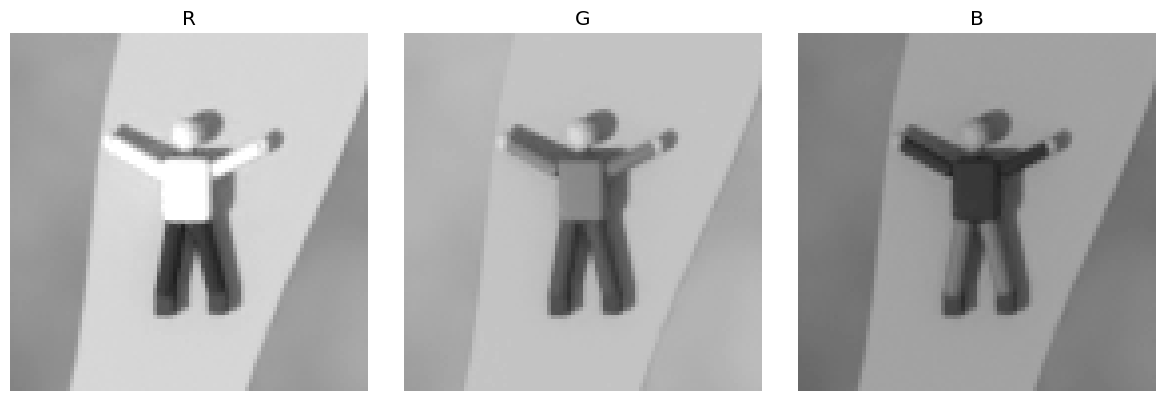

In [6]:
fig, eixos = plt.subplots(1, 3, figsize=(12, 4))
for canal, eixo, nome in zip(range(3), eixos, ["R", "G", "B"]):
    eixo.imshow(recorte[:, :, canal], cmap="gray", vmin=0, vmax=255)
    eixo.set_title(nome)
    eixo.axis("off")
plt.tight_layout()
plt.show()

Neste fluxo, Pillow fornece os canais na ordem RGB. O carregamento colorido padrão de OpenCV utiliza BGR; ao combinar bibliotecas, a ordem dos canais deve ser conferida. Um `shape` correto, isoladamente, não garante cores corretas.

## Altura de captura e tamanho aparente

As duas capturas seguintes usam a mesma cena, lente de 35 mm, largura de sensor de 36 mm, orientação nadir e resolução de $640\times640$ pixels. A posição vertical da câmera muda de 25 m para 50 m em relação ao plano de referência $z=0$.

**Nadir** indica a direção vertical para baixo. Para uma câmera nadir e um terreno plano, aumentar a altura aumenta a área de terreno observada. Objetos elevados, como pessoas e árvores, têm profundidades diferentes das do plano.

Antes de observar a segunda imagem, formule uma previsão: a pessoa deve ocupar a mesma quantidade de pixels? A quantidade total de pixels do arquivo também muda?

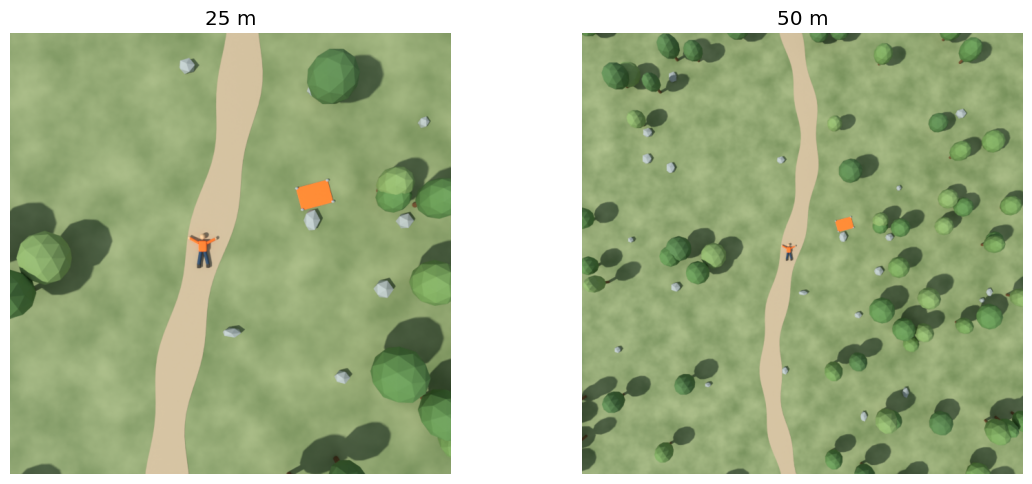

In [7]:
imagem_alta = np.array(Image.open(pasta_dados / "cena-50m.png").convert("RGB"))
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, foto, titulo in zip(eixos, [imagem, imagem_alta], ["25 m", "50 m"]):
    eixo.imshow(foto)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

### Escala nominal no plano de referência

Para pixels quadrados e sensor ajustado à largura da imagem, a distância focal horizontal em pixels é

$$f_x=f\frac{W}{s_x},$$

em que $f$ e a largura do sensor $s_x$ usam a mesma unidade. No plano perpendicular ao eixo óptico, a uma distância $h$, a amostragem nominal é $g=h/f_x$, em metros por pixel quando $h$ é dado em metros.

Esse valor é usualmente chamado de **GSD nominal** no plano de referência. Ele não determina sozinho a capacidade de distinguir objetos e não vale indistintamente para qualquer relevo, superfície elevada ou inclinação da câmera.

In [8]:
largura_px = imagem.shape[1]
focal_px = metadados["lente_mm"] * largura_px / metadados["sensor_horizontal_mm"]
print("Distância focal horizontal em pixels:", round(focal_px, 2))
for altura_m in [25, 50]:
    gsd_m = altura_m / focal_px
    print(altura_m, "m:", round(100 * gsd_m, 2), "cm por pixel no plano z=0")

Distância focal horizontal em pixels: 622.22
25 m: 4.02 cm por pixel no plano z=0
50 m: 8.04 cm por pixel no plano z=0


### Medir usando uma referência conhecida

O conjunto inclui **máscaras de referência** da superfície visível da pessoa. Elas foram obtidas da geometria da cena durante a renderização e excluem sombra e lona. Não são previsões de um algoritmo de visão computacional.

O branco identifica a pessoa e o preto identifica o restante. Os arquivos incluem valores intermediários nas bordas; o limiar 128 define a convenção de binarização deste exercício. A extensão vertical da máscara é o intervalo inclusivo entre a primeira e a última linha ocupadas pela pessoa. Ela é medida em pixels e não corresponde à altura física da pessoa em metros.

In [9]:
referencia = np.array(Image.open(pasta_dados / "pessoa-25m.png")) >= 128
referencia_alta = np.array(Image.open(pasta_dados / "pessoa-50m.png")) >= 128
for nome, mascara in [("25 m", referencia), ("50 m", referencia_alta)]:
    linhas, colunas = np.where(mascara)
    extensao = linhas.max() - linhas.min() + 1
    print(nome, "| extensão vertical:", extensao, "pixels | área:", mascara.sum())

25 m | extensão vertical: 50 pixels | área: 632
50 m | extensão vertical: 25 pixels | área: 153


Neste experimento, a extensão vertical cai de 50 para 25 pixels. A área binária passa de 632 para 153 pixels; a relação não é exatamente quatro devido à geometria, à amostragem e à binarização das bordas. A altura da câmera e a profundidade de cada ponto da pessoa não são grandezas idênticas.

## Redimensionamento após a captura

Agora a câmera permanece fixa. A imagem já renderizada será reduzida para 160 e 80 pixels de lado com interpolação bilinear. Trata-se de reamostragem de um arquivo, e não de uma nova captura a outra altura.

Para comparar a mesma região, as versões reduzidas serão ampliadas novamente para o tamanho original antes do recorte. A ampliação alinha a visualização, mas não recupera o detalhe perdido na redução.

In [10]:
original_pil = Image.fromarray(imagem)
reduzidas = [original_pil.resize((n, n), Image.Resampling.BILINEAR) for n in [160, 80]]
reconstruidas = [np.array(img.resize((640, 640), Image.Resampling.NEAREST)) for img in reduzidas]
recortes = [recorte] + [img[270:360, 235:325] for img in reconstruidas]

Os painéis abaixo mostram a mesma ROI com o mesmo tamanho de exibição. Observe o contorno dos braços, a separação entre pernas e os limites entre roupa e terreno.

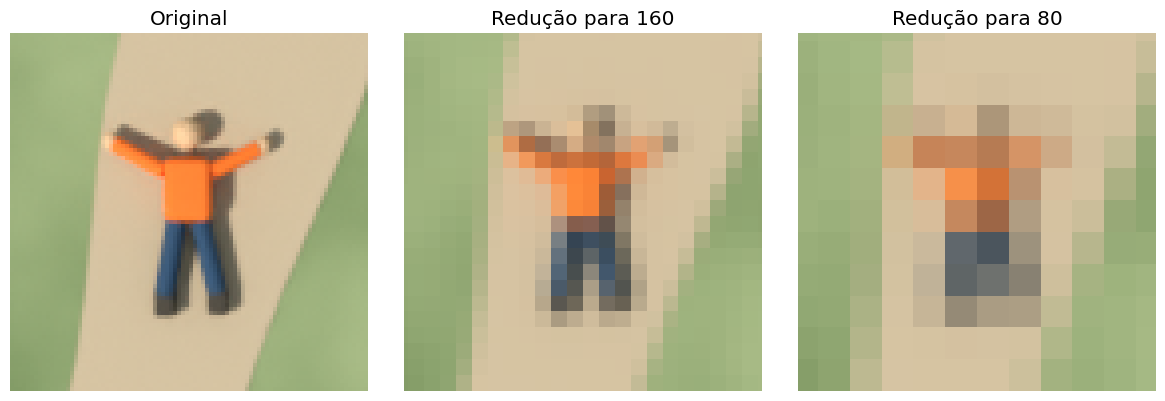

In [11]:
fig, eixos = plt.subplots(1, 3, figsize=(12, 4))
for eixo, roi, titulo in zip(eixos, recortes, ["Original", "Redução para 160", "Redução para 80"]):
    eixo.imshow(roi, interpolation="nearest")
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

Parte da evidência espacial deixa de estar disponível nas representações reduzidas. Esse resultado não estabelece um número universal de pixels necessário para detectar uma pessoa; o efeito depende também de contraste, pose, oclusão e método utilizado.

## Iluminação e aparência

Na próxima captura, câmera, objetos e materiais permanecem fixos. Apenas a orientação do Sol foi modificada. As sombras e os valores RGB podem mudar mesmo quando a categoria e a posição dos objetos permanecem iguais.

A comparação é realizada nos mesmos índices da imagem. Os valores exportados são códigos de cor; sua diferença não deve ser tratada como medição direta de potência luminosa ou radiância.

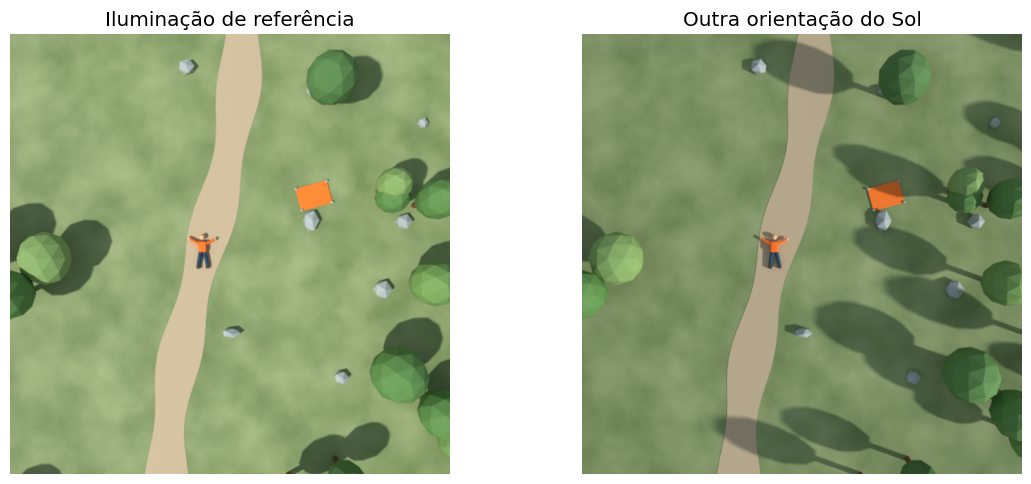

In [12]:
imagem_luz = np.array(Image.open(pasta_dados / "cena-luz.png").convert("RGB"))
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, foto, titulo in zip(eixos, [imagem, imagem_luz], ["Iluminação de referência", "Outra orientação do Sol"]):
    eixo.imshow(foto)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

O pixel escolhido anteriormente permite verificar numericamente essa mudança de aparência. A comparação isolada de um pixel é ilustrativa; uma avaliação de contraste ou iluminação exigiria uma definição de medida e de região.

In [13]:
print("RGB na referência:", imagem[linha, coluna])
print("RGB com outro Sol:", imagem_luz[linha, coluna])
referencia_luz = np.array(Image.open(pasta_dados / "pessoa-luz.png")) >= 128
print("Máscaras visíveis iguais:", np.array_equal(referencia, referencia_luz))

RGB na referência: [255 138  58]
RGB com outro Sol: [240 114  46]
Máscaras visíveis iguais: True


## Uma regra de segmentação por cor

Considere a hipótese de que a roupa laranja possa ser selecionada a partir de seus valores RGB. A regra didática abaixo combina três condições: canal vermelho acima de 180, verde abaixo de 170 e azul abaixo de 100.

Os limiares foram escolhidos para esta demonstração e permanecerão fixos nas comparações seguintes. Não houve treinamento, estimação probabilística ou calibração para imagens reais. A saída é uma **máscara booleana de seleção por cor**, com `True` nos pixels que satisfazem simultaneamente as condições.

In [14]:
r = imagem[:, :, 0]
g = imagem[:, :, 1]
b = imagem[:, :, 2]
selecao = (r > 180) & (g < 170) & (b < 100)
print("Formato:", selecao.shape, "| tipo:", selecao.dtype)
print("Pixels selecionados:", selecao.sum())

Formato: (640, 640) | tipo: bool
Pixels selecionados: 1862


O operador `&` combina condições elemento a elemento. Cada comparação produz uma matriz booleana com a mesma grade espacial da imagem; os parênteses preservam a ordem desejada das operações.

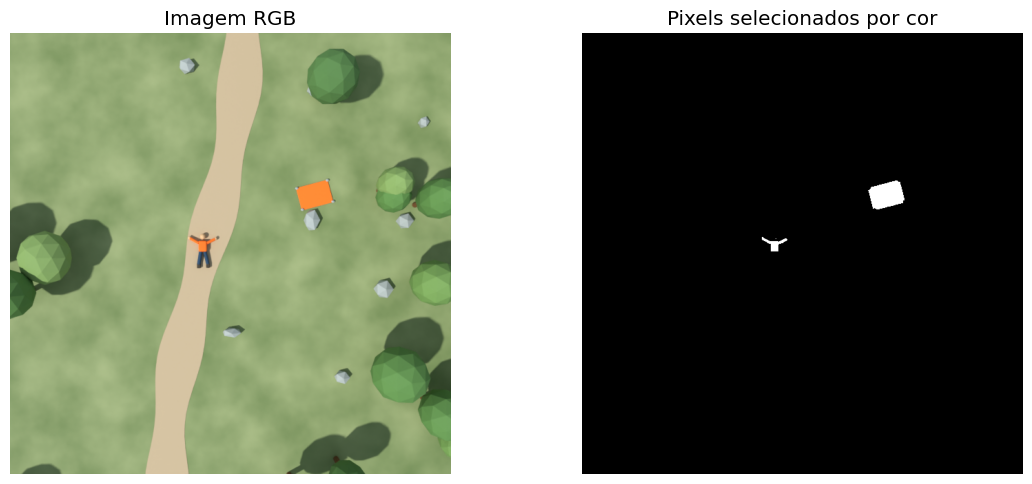

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
eixos[0].imshow(imagem)
eixos[0].set_title("Imagem RGB")
eixos[1].imshow(selecao, cmap="gray", vmin=0, vmax=1)
eixos[1].set_title("Pixels selecionados por cor")
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()
plt.show()

A seleção inclui parte da roupa e grande parte da lona. Ela também omite partes da pessoa cujas cores não satisfazem os limiares. A propriedade “cor compatível com a regra” não é equivalente à categoria “pessoa”.

### Seleção e referência respondem a perguntas diferentes

Para verificar se a regra poderia funcionar como aproximação de uma segmentação de pessoa, será comparada com a máscara da **pessoa visível inteira**: roupa, pele, calça e botas. Não estamos avaliando a qualidade de uma segmentação de “laranja”, pois a referência possui outro significado semântico.

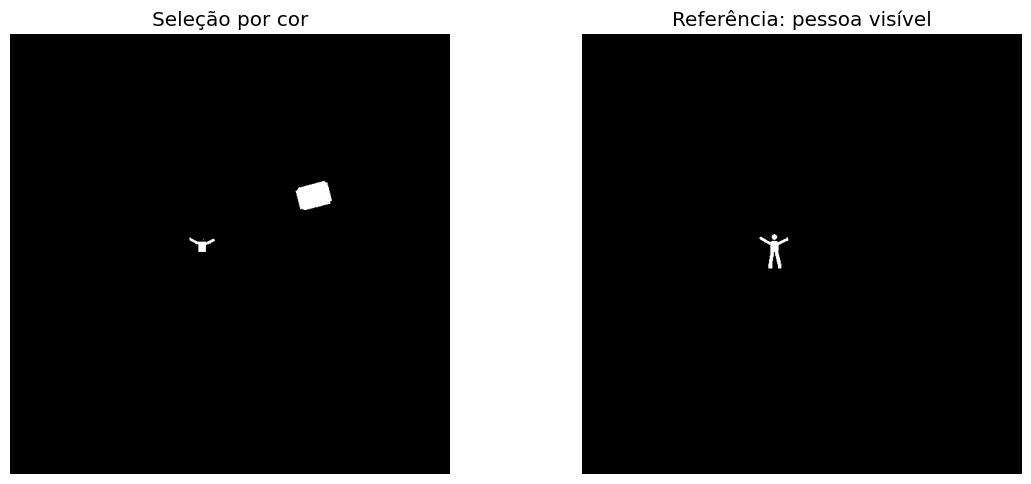

In [16]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, mascara, titulo in zip(eixos, [selecao, referencia], ["Seleção por cor", "Referência: pessoa visível"]):
    eixo.imshow(mascara, cmap="gray", vmin=0, vmax=1)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

## Avaliação por pixel

Com a categoria de interesse fixada como “pessoa visível”, cada pixel pode ser classificado como verdadeiro positivo (VP), falso positivo (FP), falso negativo (FN) ou verdadeiro negativo (VN). Por exemplo, um pixel da lona selecionado pela regra é um FP; um pixel da calça da pessoa que não foi selecionado é um FN.

Essas contagens descrevem **pixels**, e não quantidades de pessoas detectadas ou perdidas.

In [17]:
verdadeiros_positivos = selecao & referencia
falsos_positivos = selecao & ~referencia
falsos_negativos = ~selecao & referencia
vp = np.count_nonzero(verdadeiros_positivos)
fp = np.count_nonzero(falsos_positivos)
fn = np.count_nonzero(falsos_negativos)
print("VP:", vp, "FP:", fp, "FN:", fn)

VP: 275 FP: 1587 FN: 357


Precisão e revocação resumem dois aspectos distintos:

$$\mathrm{Precisão}=\frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FP}}, \qquad
\mathrm{Revocação}=\frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FN}}.$$

A precisão indica a fração de pixels selecionados que pertence à pessoa. A revocação (*recall*) indica a fração dos pixels da pessoa que foi selecionada. Os dois denominadores são positivos neste exemplo.

In [18]:
precisao = vp / (vp + fp)
revocacao = vp / (vp + fn)
print("Precisão por pixel:", round(100 * precisao, 2), "%")
print("Revocação por pixel:", round(100 * revocacao, 2), "%")

Precisão por pixel: 14.77 %
Revocação por pixel: 43.51 %


Na referência, a precisão é aproximadamente 14,77% e a revocação é 43,51%. O grande número de pixels da lona reduz a precisão; partes da pessoa com outras cores reduzem a revocação. São resultados deste exercício, não métricas de um detector de objetos, AP ou mAP.

O mapa de erros permite localizar os resultados: verde para VP, magenta para FP e azul para FN. Os demais pixels permanecem pretos. A vista completa evidencia a lona; a ROI permite examinar os erros sobre a pessoa.

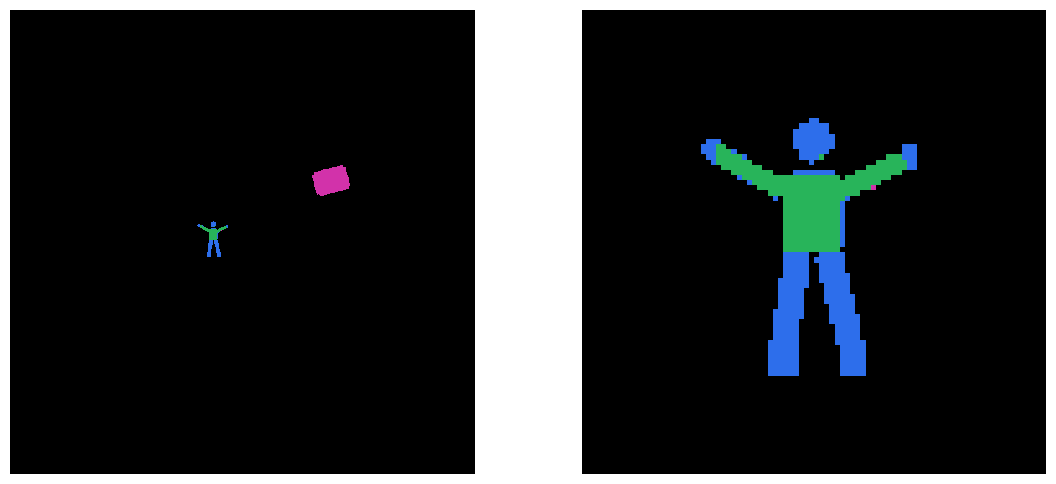

In [19]:
mapa_erros = np.zeros_like(imagem)
mapa_erros[verdadeiros_positivos] = [40, 180, 90]
mapa_erros[falsos_positivos] = [210, 50, 170]
mapa_erros[falsos_negativos] = [45, 110, 235]
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for eixo, mapa in zip(eixos, [mapa_erros, mapa_erros[270:360, 235:325]]):
    eixo.imshow(mapa, interpolation="nearest")
    eixo.axis("off")
plt.tight_layout()
plt.show()

## Manter a regra e alterar a condição

A comparação seguinte reutiliza exatamente os mesmos limiares. A função apenas encapsula as três operações já examinadas.

In [20]:
def segmentar_cor(rgb):
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    return (r > 180) & (g < 170) & (b < 100)

A função de avaliação abaixo aplica as mesmas definições por pixel. Se uma razão não tiver denominador positivo, o resultado será `nan`, indicando que a medida não está definida naquele caso.

In [21]:
def avaliar_pixels(mascara, alvo):
    vp = np.count_nonzero(mascara & alvo)
    fp = np.count_nonzero(mascara & ~alvo)
    fn = np.count_nonzero(~mascara & alvo)
    precisao = vp / (vp + fp) if vp + fp else np.nan
    revocacao = vp / (vp + fn) if vp + fn else np.nan
    return precisao, revocacao

As três imagens são vistas relacionadas da mesma cena. Esta comparação controla condições específicas e não constitui uma avaliação de generalização em um conjunto de teste independente.

In [22]:
condicoes = [
    ("Referência, 25 m", imagem, referencia),
    ("Altura, 50 m", imagem_alta, referencia_alta),
    ("Outra iluminação", imagem_luz, referencia_luz),
]
for nome, rgb, alvo in condicoes:
    p, r = avaliar_pixels(segmentar_cor(rgb), alvo)
    print(nome, "| precisão:", round(100 * p, 2), "| revocação:", round(100 * r, 2))

Referência, 25 m | precisão: 14.77 | revocação: 43.51
Altura, 50 m | precisão: 14.92 | revocação: 46.41
Outra iluminação | precisão: 20.89 | revocação: 40.66


Com a outra iluminação, a precisão aumenta para cerca de 20,89%, enquanto a revocação diminui para 40,66%. A mudança não representa uma melhora ou piora uniforme: menos pixels da lona passam pela regra, e menos pixels da pessoa também são selecionados. Interpretar os valores exige considerar a referência, o tipo de erro e o objetivo da aplicação.

## Oclusão: presença na cena e visibilidade

Uma pessoa pode continuar presente na cena e ter parte de sua superfície bloqueada por outro objeto. No exemplo seguinte, foi acrescentado um pequeno oclusor diante de parte da pessoa, mantendo a câmera e a iluminação da referência.

A imagem pode mudar tanto pelo bloqueio da linha de visão quanto pela sombra introduzida pelo novo objeto. A alteração controlada é a presença do oclusor; seus efeitos físicos não se limitam à máscara da pessoa.

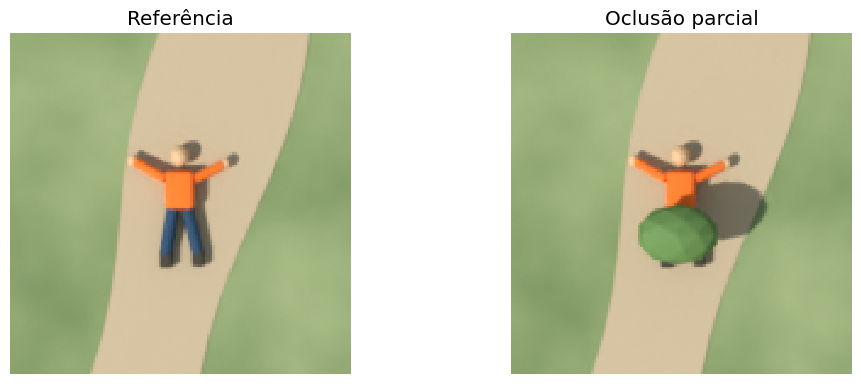

In [23]:
imagem_oclusao = np.array(Image.open(pasta_dados / "cena-oclusao.png").convert("RGB"))
referencia_oclusao = np.array(Image.open(pasta_dados / "pessoa-oclusao.png")) >= 128
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
for eixo, rgb, titulo in zip(eixos, [imagem, imagem_oclusao], ["Referência", "Oclusão parcial"]):
    eixo.imshow(rgb[245:385, 210:350], interpolation="nearest")
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

As máscaras fornecidas representam somente a superfície visível. Ao avaliar a variante com oclusão, deve-se usar sua máscara correspondente. Exigir que uma segmentação visível marque partes completamente escondidas mudaria a definição da tarefa.

In [24]:
print("Pixels visíveis na referência:", referencia.sum())
print("Pixels visíveis com oclusão:", referencia_oclusao.sum())
p, r = avaliar_pixels(segmentar_cor(imagem_oclusao), referencia_oclusao)
print("Precisão por pixel:", round(100 * p, 2), "%")
print("Revocação por pixel:", round(100 * r, 2), "%")

Pixels visíveis na referência: 632
Pixels visíveis com oclusão: 388
Precisão por pixel: 12.99 %
Revocação por pixel: 61.08 %


Com oclusão, a precisão é 12,99% e a revocação é 61,08%. O aumento da revocação não demonstra melhora no reconhecimento: a referência visível perdeu pixels, incluindo partes que antes eram falsos negativos. A quantidade de pixels visíveis não corresponde diretamente à fração de superfície física exposta. A projeção, a amostragem e a convenção de bordas participam dessa contagem. A identificação de objetos parcialmente ocluídos exige evidências e hipóteses além da seleção de cor examinada aqui.

## Da regra explícita ao aprendizado

O procedimento construído utiliza critérios definidos manualmente. Um modelo aprendido ajusta parâmetros a partir de exemplos e de uma função objetivo. Ele também pode aprender atalhos indesejados se as classes forem associadas a uma cor, posição ou condição de captura de forma sistemática.

As quatro imagens desta aula podem ser organizadas em um lote para compreender a representação utilizada por modelos. A divisão por 255 apenas muda a escala numérica para o intervalo de 0 a 1; ela não lineariza a resposta de cor e não substitui o pré-processamento especificado por cada modelo.

In [25]:
lote = np.stack([imagem, imagem_alta, imagem_luz, imagem_oclusao])
lote = lote.astype(np.float32) / 255
print("Formato do lote:", lote.shape)
print("Tipo:", lote.dtype)
print("Faixa:", lote.min(), lote.max())

Formato do lote: (4, 640, 640, 3)
Tipo: float32
Faixa: 0.03529412 1.0


O formato é $(N,H,W,C)$, com $N=4$ imagens relacionadas. Um lote é uma organização dos dados; sua existência não implica que exista um conjunto adequado de treinamento ou uma avaliação independente.

Na continuidade do curso, esses conceitos permitem estudar tensores, parâmetros, perda e otimização. Para avaliar aprendizado, será necessário ampliar a variedade de cenas e separar os conjuntos antes de gerar vistas muito semelhantes. Resultados em imagens sintéticas não comprovam desempenho em imagens reais.

## Atividade de consolidação

- Escolha um dos três limiares na função `segmentar_cor`. Antes de alterá-lo, registre sua previsão sobre os pixels da roupa, da lona e do terreno. Reexecute a definição da função e a comparação das condições. Para visualizar a nova máscara, use `plt.imshow(segmentar_cor(imagem), cmap="gray")`. Compare também precisão e revocação e, ao terminar, restaure os limiares originais.
- Explique por que reduzir a resolução do arquivo e aumentar a altura da câmera são operações diferentes, embora ambas possam reduzir o detalhe de um alvo.
- Identifique uma situação em que uma máscara aparentemente pequena gere muitos falsos positivos em relação à categoria “pessoa”.
- Descreva quais alterações seriam necessárias nos dados para avaliar um modelo que reconheça pessoas com roupas de outras cores e sob oclusão.

Esses ajustes são exploração do exemplo conhecido. Não devem ser apresentados como otimização comprovada para novas cenas.

## Síntese dos fundamentos

A representação digital resulta de uma cadeia de formação e processamento da imagem. A geometria da captura influencia tamanho aparente e campo observado; a amostragem e o redimensionamento influenciam o detalhe disponível; iluminação e oclusão modificam a evidência visual.

A interpretação depende de uma tarefa explícita. Uma regra que seleciona cor pode ser implementada corretamente e ainda ser inadequada para identificar pessoas. Referências bem definidas e análise dos erros permitem distinguir o funcionamento do código da adequação do método ao problema.

## Dados utilizados

As imagens são sintéticas e representam uma mesma cena tridimensional sob condições controladas. Os parâmetros de captura e a definição das máscaras estão em `dados/metadados.json`.

As máscaras descrevem a superfície visível da pessoa e servem de referência para avaliação por pixel. Não são previsões de um modelo. A ilustração da câmera explica a geometria de captura e não integra o lote de imagens aéreas utilizado nos experimentos.